In [1]:
import pandas as pd

# Read CSV
std_data = pd.read_csv('survey_student.csv')

# Rename all columns
std_data.columns = [
    'Timestamp',
    'Sex',
    'Matric_GPA',
    'Year_2023',
    'Faculty',
    'Uni_GPA',
    'Accommodation',
    'Allowance',
    'Scholarship',
    'Study_Hours',
    'Party_Freq',
    'Alcohol_Drinks',
    'Missed_Classes',
    'Failed_Modules',
    'Relationship',
    'Parent_Approval',
    'Parent_Relationship'
]

# Drop Timestamp column
std_data.drop('Timestamp', axis=1, inplace=True)

print(std_data.head())

      Sex  Matric_GPA Year_2023                         Faculty  Uni_GPA  \
0  Female        76.0  2nd Year          Arts & Social Sciences     72.0   
1    Male        89.0  2nd Year  Economic & Management Sciences     75.0   
2    Male        76.0  1st Year                    AgriSciences     55.0   
3    Male        89.0  2nd Year                     Engineering     84.0   
4  Female        74.0  2nd Year          Arts & Social Sciences     52.0   

                                     Accommodation        Allowance  \
0  Private accommodation/ stay with family/friends   R 4001- R 5000   
1  Private accommodation/ stay with family/friends  R 7001 - R 8000   
2  Private accommodation/ stay with family/friends   R 4001- R 5000   
3  Private accommodation/ stay with family/friends  R 6001 - R 7000   
4  Private accommodation/ stay with family/friends   R 4001- R 5000   

           Scholarship Study_Hours     Party_Freq Alcohol_Drinks  \
0                   No          8+  Only weekend

In [2]:
std_data.head()

,Sex,Matric_GPA,Year_2023,Faculty,Uni_GPA,Accommodation,Allowance,Scholarship,Study_Hours,Party_Freq,Alcohol_Drinks,Missed_Classes,Failed_Modules,Relationship,Parent_Approval,Parent_Relationship
0,Female,76.0,2nd Year,Arts & Social Sciences,72.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,8+,Only weekends,8+,3,0,Yes,Yes,Very close
1,Male,89.0,2nd Year,Economic & Management Sciences,75.0,Private accommodation/ stay with family/friends,R 7001 - R 8000,"Yes (NSFAS, etc...)",8+,Only weekends,3-5,4+,0,No,Yes,Very close
2,Male,76.0,1st Year,AgriSciences,55.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,2,8+,3,0,No,Yes,Very close
3,Male,89.0,2nd Year,Engineering,84.0,Private accommodation/ stay with family/friends,R 6001 - R 7000,No,3-5,3,8+,2,0,Yes,Yes,Very close
4,Female,74.0,2nd Year,Arts & Social Sciences,52.0,Private accommodation/ stay with family/friends,R 4001- R 5000,No,3-5,Only weekends,5-8,1,3,No,Yes,Fair


In [3]:
std_data.describe()

,Matric_GPA,Uni_GPA
count,399.000000,320.000000
mean,77.989724,66.268469
std,7.048618,9.147906
min,34.000000,30.000000
25%,74.000000,60.000000
50%,78.000000,65.000000
75%,83.000000,73.000000
max,99.000000,95.220000


In [4]:
std_data.shape

(406, 16)

In [5]:
std_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sex                  404 non-null    str    
 1   Matric_GPA           399 non-null    float64
 2   Year_2023            333 non-null    str    
 3   Faculty              399 non-null    str    
 4   Uni_GPA              320 non-null    float64
 5   Accommodation        383 non-null    str    
 6   Allowance            375 non-null    str    
 7   Scholarship          398 non-null    str    
 8   Study_Hours          403 non-null    str    
 9   Party_Freq           404 non-null    str    
 10  Alcohol_Drinks       404 non-null    str    
 11  Missed_Classes       403 non-null    str    
 12  Failed_Modules       403 non-null    str    
 13  Relationship         403 non-null    str    
 14  Parent_Approval      402 non-null    str    
 15  Parent_Relationship  403 non-null    str    
dtypes

In [6]:
std_data.isna().sum()

Sex                     2
Matric_GPA              7
Year_2023              73
Faculty                 7
Uni_GPA                86
Accommodation          23
Allowance              31
Scholarship             8
Study_Hours             3
Party_Freq              2
Alcohol_Drinks          2
Missed_Classes          3
Failed_Modules          3
Relationship            3
Parent_Approval         4
Parent_Relationship     3
dtype: int64

<Axes: xlabel='Alcohol_Drinks'>

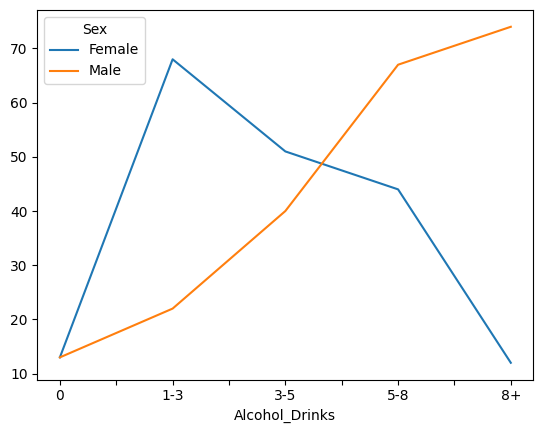

In [7]:
# Gender Specific Alcohol Consumption

pd.crosstab(
    std_data.Sex,
    std_data.Alcohol_Drinks
).T.plot(kind = 'line')

In [8]:
std_data.Parent_Relationship.value_counts()

Parent_Relationship
Very close    269
Close          97
Fair           35
Distant         2
Name: count, dtype: int64

In [9]:
groupped = std_data.groupby(['Parent_Relationship'])

In [10]:
relation = groupped[['Uni_GPA', 'Matric_GPA']].agg(('min', 'max', 'std'))
relation

Uni_GPA                  Matric_GPA                 
                        min    max       std        min    max       std
Parent_Relationship                                                     
Close                  50.0  95.22  8.151525       60.0  98.33  6.010535
Distant                88.0  89.00  0.707107       85.0  98.00  9.192388
Fair                   50.0  85.00  8.925498       55.0  95.50  7.964601
Very close             30.0  92.00  9.282383       34.0  99.00  7.211299

In [11]:
Corre = std_data[['Matric_GPA', 'Uni_GPA']].corr()
Corre

,Matric_GPA,Uni_GPA
Matric_GPA,1.000000,0.299104
Uni_GPA,0.299104,1.000000


In [12]:
import seaborn as sns

<Axes: xlabel='Matric_GPA', ylabel='Uni_GPA'>

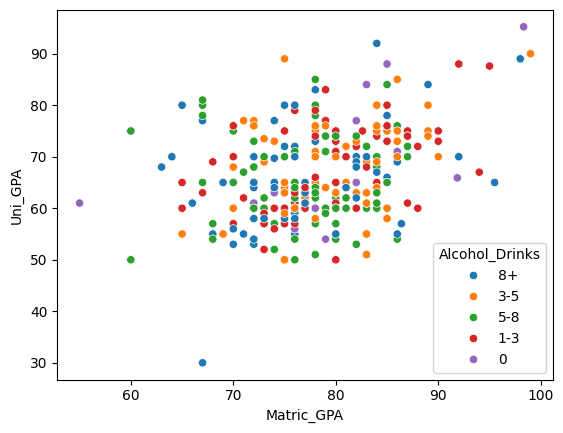

In [13]:
sns.scatterplot(std_data, x = 'Matric_GPA', y = 'Uni_GPA', hue='Alcohol_Drinks')

<Axes: xlabel='Matric_GPA'>

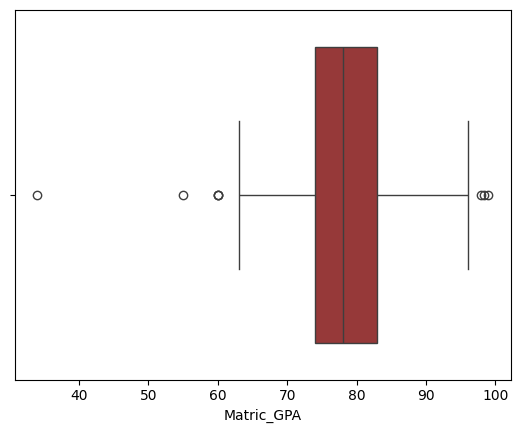

In [14]:
total = std_data['Matric_GPA']

sns.boxplot(total,
            orient='h', 
            color='Brown')